# Supervised Learning: Stellar Parameter Prediction

This notebook trains supervised regression models to predict effective temperature (`INPUT_TEFF`), surface gravity (`INPUT_LOGG`), and metallicity (`INPUT_FE_H`) from continuum-normalized MaStar spectra.

The workflow is organized around the final project requirements:

1. Data setup and stratified train/test split  
2. Baseline and advanced supervised models  
3. Cross-validation and Ridge + PCA diagnostics  
4. Feature importance and ablation  
5. Sensitivity analysis  
6. Failure analysis with specific failed records  


## 1. Load Data and Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score

labeled_meta = pd.read_csv("mastar_labeled_meta.csv")

labeled_flux = np.load("mastar_labeled_spectra.npy")

wave = np.load("mastar_wave.npy")

print("labeled meta: ",labeled_meta.shape)
print("labeled flux: ",labeled_flux.shape)
print(wave.shape)

labeled meta:  (3291, 8)
labeled flux:  (3291, 4563)
(4563,)


## 2. Define Features and Targets

In [ ]:
# Define input features X and targets y

# X = continuum-normalized spectra
# Each row is one star.
# Each column is normalized flux at one wavelength.
X = labeled_flux

# y = target stellar parameters
target_cols = ["INPUT_TEFF", "INPUT_LOGG", "INPUT_FE_H"]
y = labeled_meta[target_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3291, 4563)
y shape: (3291, 3)


## 3. Stratified Train/Test Split

In [ ]:
# Stratified train/test split
# We stratify using SPECTRAL_TYPE.
# This keeps the spectral type distribution similar in train and test sets.
# This matters because the data is skewed toward cooler stars.

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X,
    y,
    labeled_meta,
    test_size=0.2,
    random_state=42,
    stratify=labeled_meta["SPECTRAL_TYPE"]
)

print("Train X:", X_train.shape)
print("Test X:", X_test.shape)

print("\nFull spectral type distribution:")
print(labeled_meta["SPECTRAL_TYPE"].value_counts(normalize=True))

print("\nTrain spectral type distribution:")
print(meta_train["SPECTRAL_TYPE"].value_counts(normalize=True))

print("\nTest spectral type distribution:")
print(meta_test["SPECTRAL_TYPE"].value_counts(normalize=True))

Train X: (2632, 4563)
Test X: (659, 4563)

Full spectral type distribution:
SPECTRAL_TYPE
K    0.588271
G    0.192647
F    0.142814
A    0.054391
M    0.021878
Name: proportion, dtype: float64

Train spectral type distribution:
SPECTRAL_TYPE
K    0.588146
G    0.192629
F    0.142857
A    0.054331
M    0.022036
Name: proportion, dtype: float64

Test spectral type distribution:
SPECTRAL_TYPE
K    0.588771
G    0.192716
F    0.142640
A    0.054628
M    0.021244
Name: proportion, dtype: float64


## 4. Evaluation Function

In [ ]:
# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    """
    Evaluate multi-output regression result.

    MAE:
        Average absolute prediction error.
        i.e. Teff MAE = 200 means average error is 200 K.

    R2:
        Measures how much variation the model explains compared to variation from predicting average.
    """

    results = []

    for i, target in enumerate(target_cols):
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        r2 = r2_score(y_true.iloc[:, i], y_pred[:, i])

        results.append({
            "Model": model_name,
            "Target": target,
            "MAE": mae,
            "R2": r2
        })

    return pd.DataFrame(results)

## 5. Ridge Regression Baseline

In [ ]:
# Ridge Regression without PCA
# Ridge is useful as a linear baseline and handles many correlated features
# better than ordinary linear regression.

ridge_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_no_pca.fit(X_train, y_train)
ridge_no_pca_pred = ridge_no_pca.predict(X_test)

ridge_no_pca_results = evaluate_model(
    y_test,
    ridge_no_pca_pred,
    "Ridge without PCA"
)

display(ridge_no_pca_results)

,Model,Target,MAE,R2
0,Ridge without PCA,INPUT_TEFF,478.974201,0.063434
1,Ridge without PCA,INPUT_LOGG,0.793714,-0.441123
2,Ridge without PCA,INPUT_FE_H,0.501452,-0.493322


In [ ]:
# Ridge Regression with PCA


# PCA reduces the 4563 wavelength features into fewer components.
# n_components=0.95 means we use number of components that explains 95% of the variance in the spectra.
#
# PCA is inside the pipeline, so PCA is fit only on the training set.
# This avoids data leakage.

ridge_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("ridge", Ridge(alpha=1.0))
])

ridge_with_pca.fit(X_train, y_train)
ridge_with_pca_pred = ridge_with_pca.predict(X_test)

ridge_with_pca_results = evaluate_model(
    y_test,
    ridge_with_pca_pred,
    "Ridge with PCA"
)

display(ridge_with_pca_results)


,Model,Target,MAE,R2
0,Ridge with PCA,INPUT_TEFF,175.635516,0.931074
1,Ridge with PCA,INPUT_LOGG,0.327134,0.788546
2,Ridge with PCA,INPUT_FE_H,0.228188,0.738636


## 6. Ridge + PCA Feature Interpretation

In [ ]:

# Feature extraction from Ridge with PCA


# Load wavelength axis.
# Each value corresponds to one wave feature column.
wave = np.load("mastar_wave.npy")

# Get PCA and Ridge objects from the trained pipeline.
pca_model = ridge_with_pca.named_steps["pca"]
ridge_model = ridge_with_pca.named_steps["ridge"]

# Ridge coefficients are currently in PCA component space.
# Shape: (3 targets, number of PCA components = 673)
ridge_coef_pca = ridge_model.coef_

# PCA components tell us how each PCA component is made from original wavelength features.
# Shape: (number of PCA components = 673, original wavelength features = 4563)
pca_loadings = pca_model.components_

print("Ridge coefficient shape:", ridge_coef_pca.shape)
print("PCA loading shape:", pca_loadings.shape)

# Project Ridge coefficients back to original wavelength space.
# Shape:
# (3, n_components) @ (n_components, 4563) = (3, 4563)
wavelength_importance = ridge_coef_pca @ pca_loadings

print("Back-projected wavelength importance shape:", wavelength_importance.shape)

Ridge coefficient shape: (3, 673)
PCA loading shape: (673, 4563)
Back-projected wavelength importance shape: (3, 4563)


In [ ]:
target_cols = ["INPUT_TEFF", "INPUT_LOGG", "INPUT_FE_H"]

top_n = 20
all_top_features = []

for target_idx, target_name in enumerate(target_cols):

    # Importance score for this target across all wavelengths
    coef_values = wavelength_importance[target_idx]

    # Use absolute value because both strong positive and strong negative effects matter
    abs_importance = np.abs(coef_values)

    # Sort wavelengths from most important to least important
    top_indices = np.argsort(abs_importance)[::-1][:top_n]

    for rank, feature_idx in enumerate(top_indices, start=1):
        all_top_features.append({
            "Target": target_name,
            "Rank": rank,
            "Feature_Index": feature_idx,
            "Wavelength_Angstrom": wave[feature_idx],
            "Coefficient": coef_values[feature_idx],
            "Abs_Importance": abs_importance[feature_idx]
        })

top_features_pca_ridge = pd.DataFrame(all_top_features)

display(top_features_pca_ridge)

,Target,Rank,Feature_Index,Wavelength_Angstrom,Coefficient,Abs_Importance
0,INPUT_TEFF,1,2584,6565.986816,-14.354256,14.354256
1,INPUT_TEFF,2,1281,4864.072266,-13.005587,13.005587
2,INPUT_TEFF,3,2583,6564.475098,-13.004536,13.004536
3,INPUT_TEFF,4,1465,5074.578613,-12.292495,12.292495
4,INPUT_TEFF,5,1279,4861.832520,-12.220401,12.220401
5,INPUT_TEFF,6,1280,4862.952148,-12.172144,12.172144
6,INPUT_TEFF,7,2585,6567.498535,-12.157731,12.157731
7,INPUT_TEFF,8,1282,4865.192383,-12.092581,12.092581
8,INPUT_TEFF,9,2586,6569.011230,-11.722731,11.722731
9,INPUT_TEFF,10,2582,6562.963867,-11.386215,11.386215


## 7. Baseline Ridge Comparison

In [ ]:
# Compare results


ridge_comparison = pd.concat(
    [ridge_no_pca_results, ridge_with_pca_results],
    ignore_index=True
)

display(ridge_comparison)

print(
    "Number of PCA components used:",
    ridge_with_pca.named_steps["pca"].n_components_
)

,Model,Target,MAE,R2
0,Ridge without PCA,INPUT_TEFF,478.974201,0.063434
1,Ridge without PCA,INPUT_LOGG,0.793714,-0.441123
2,Ridge without PCA,INPUT_FE_H,0.501452,-0.493322
3,Ridge with PCA,INPUT_TEFF,175.635516,0.931074
4,Ridge with PCA,INPUT_LOGG,0.327134,0.788546
5,Ridge with PCA,INPUT_FE_H,0.228188,0.738636


Number of PCA components used: 673


## 8. Prediction Plots

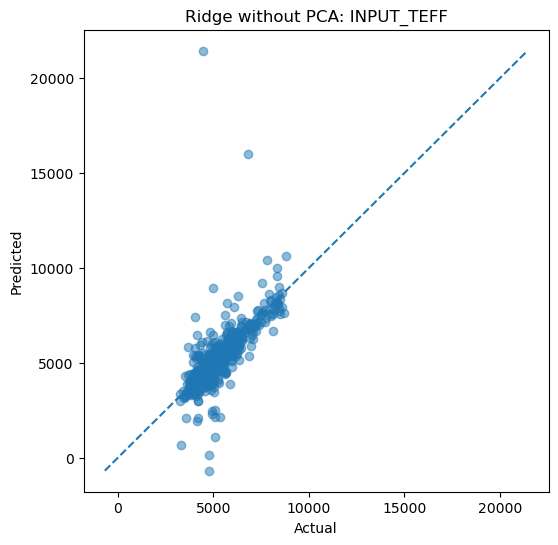

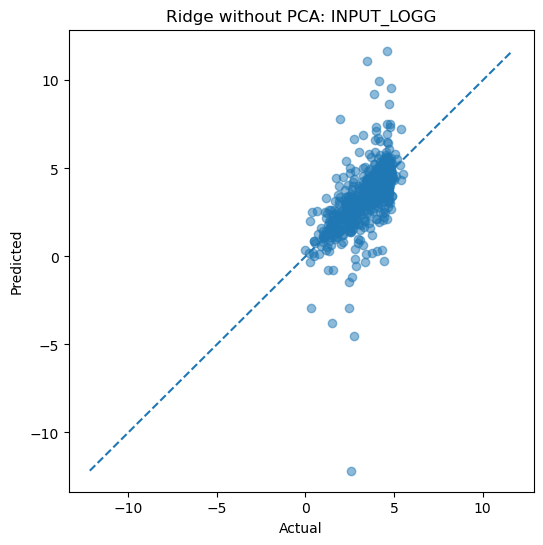

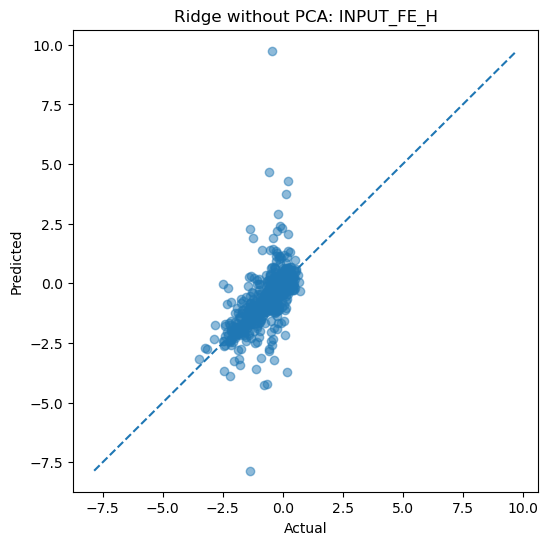

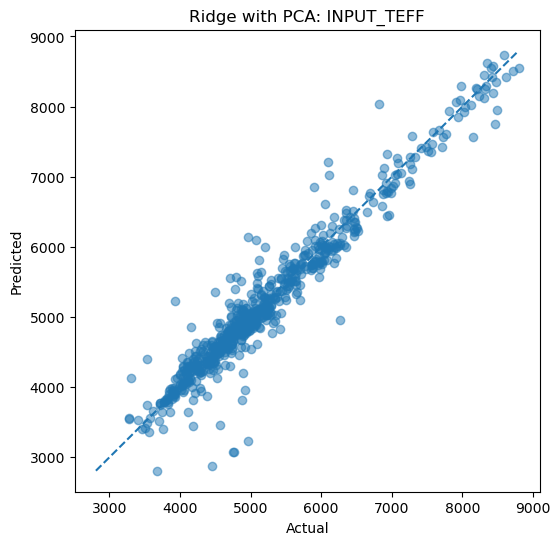

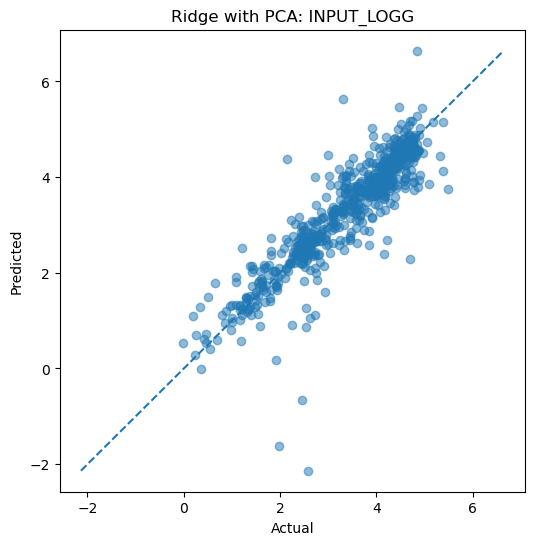

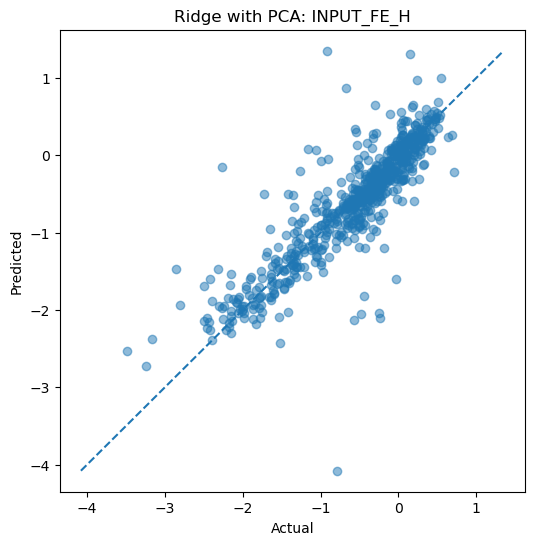

In [ ]:
# Predicted vs actual plots for Ridge Regression


def plot_predicted_vs_actual(y_true, y_pred, target_name, model_name):
    """
    Points close to the dashed diagonal line mean better predictions.
    """

    idx = target_cols.index(target_name)

    actual = y_true.iloc[:, idx]
    predicted = y_pred[:, idx]

    plt.figure(figsize=(6, 6))
    plt.scatter(actual, predicted, alpha=0.5)

    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name}: {target_name}")
    plt.show()


for target in target_cols:
    plot_predicted_vs_actual(
        y_test,
        ridge_no_pca_pred,
        target,
        "Ridge without PCA"
    )

for target in target_cols:
    plot_predicted_vs_actual(
        y_test,
        ridge_with_pca_pred,
        target,
        "Ridge with PCA"
    )

## 9. Random Forest Models

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestRegressor(random_state=42))
])

rf_no_pca.fit(X_train, y_train)
rf_no_pca_pred = rf_no_pca.predict(X_test)

rf_no_pca_results = evaluate_model(
    y_test,
    rf_no_pca_pred,
    "RandomForest without PCA"
)

display(rf_no_pca_results)

,Model,Target,MAE,R2
0,RandomForest without PCA,INPUT_TEFF,128.483515,0.967524
1,RandomForest without PCA,INPUT_LOGG,0.467603,0.727666
2,RandomForest without PCA,INPUT_FE_H,0.323940,0.653789


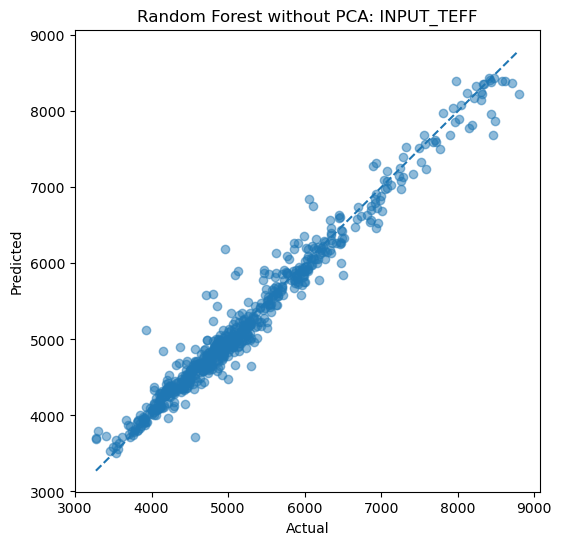

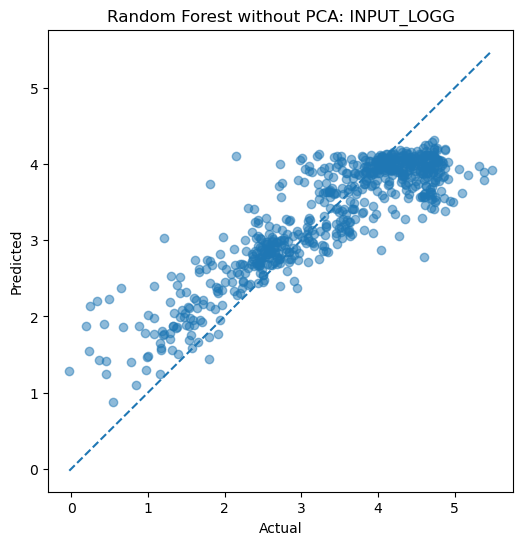

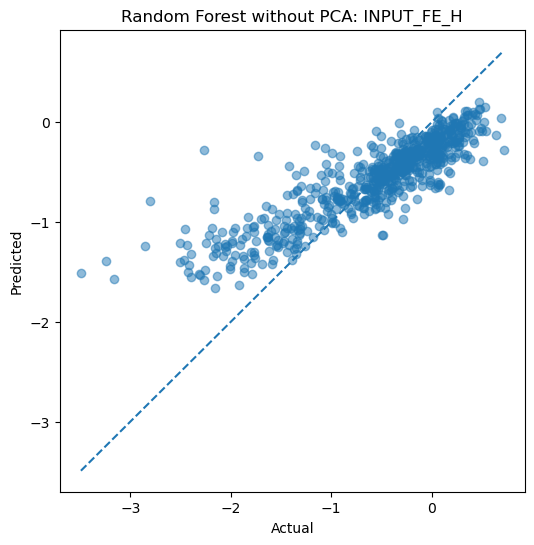

In [ ]:
for target in target_cols:
    plot_predicted_vs_actual(
        y_test,
        rf_no_pca_pred,
        target,
        "Random Forest without PCA"
    )

In [ ]:
rf_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("rf", RandomForestRegressor(random_state=42))
])

rf_with_pca.fit(X_train, y_train)
rf_with_pca_pred = rf_with_pca.predict(X_test)

rf_with_pca_results = evaluate_model(
    y_test,
    rf_with_pca_pred,
    "RandomForest with PCA"
)

display(rf_with_pca_results)

,Model,Target,MAE,R2
0,RandomForest with PCA,INPUT_TEFF,142.917063,0.961398
1,RandomForest with PCA,INPUT_LOGG,0.451894,0.711696
2,RandomForest with PCA,INPUT_FE_H,0.253870,0.759939


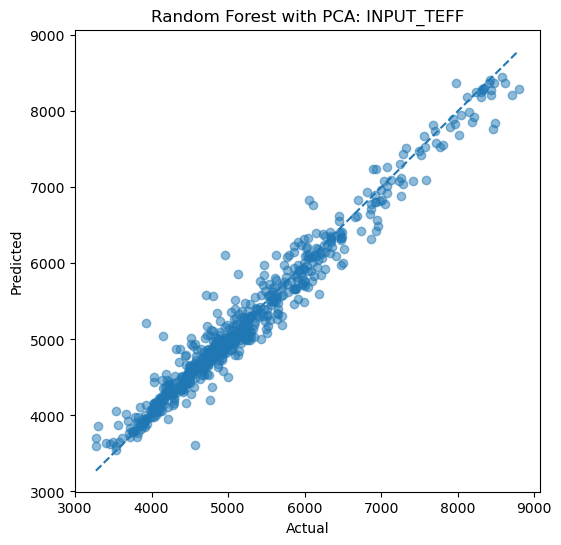

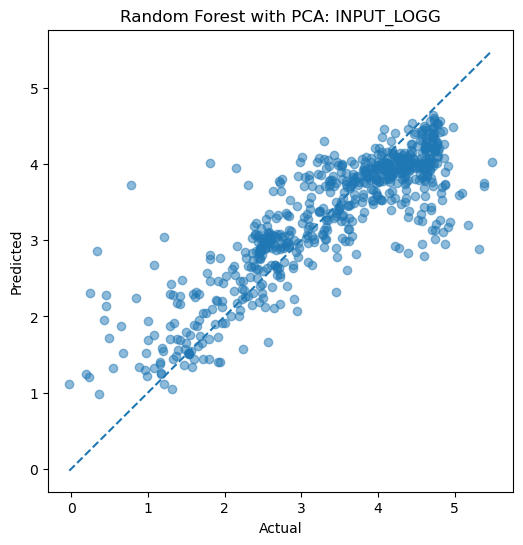

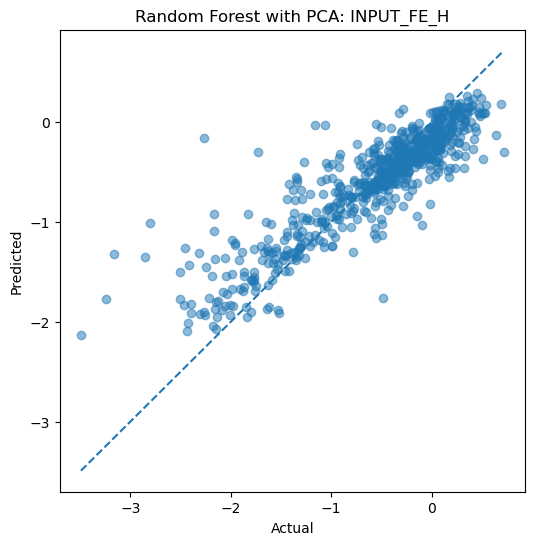

In [ ]:
for target in target_cols:
    plot_predicted_vs_actual(
        y_test,
        rf_with_pca_pred,
        target,
        "Random Forest with PCA"
    )

## 10. XGBoost Models

In [ ]:
from xgboost import XGBRegressor


target_cols = ["INPUT_TEFF", "INPUT_LOGG", "INPUT_FE_H"]

xgb_results = []
xgb_predictions = {}

for target in target_cols:

    # XGBoost without PCA
    xgb_no_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("xgb", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        ))
    ])

    xgb_no_pca.fit(X_train, y_train[target])
    pred_no_pca = xgb_no_pca.predict(X_test)

    xgb_predictions[("XGBoost without PCA", target)] = pred_no_pca

    xgb_results.append({
        "Model": "XGBoost without PCA",
        "Target": target,
        "MAE": mean_absolute_error(y_test[target], pred_no_pca),
        "R2": r2_score(y_test[target], pred_no_pca)
    })


    # XGBoost with PCA
    xgb_with_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("xgb", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        ))
    ])

    xgb_with_pca.fit(X_train, y_train[target])
    pred_with_pca = xgb_with_pca.predict(X_test)

    xgb_predictions[("XGBoost with PCA", target)] = pred_with_pca

    xgb_results.append({
        "Model": "XGBoost with PCA",
        "Target": target,
        "MAE": mean_absolute_error(y_test[target], pred_with_pca),
        "R2": r2_score(y_test[target], pred_with_pca)
    })

xgb_results_df = pd.DataFrame(xgb_results)

display(xgb_results_df)

,Model,Target,MAE,R2
0,XGBoost without PCA,INPUT_TEFF,128.543452,0.966865
1,XGBoost with PCA,INPUT_TEFF,146.813524,0.960580
2,XGBoost without PCA,INPUT_LOGG,0.268047,0.887364
3,XGBoost with PCA,INPUT_LOGG,0.316980,0.822817
4,XGBoost without PCA,INPUT_FE_H,0.170777,0.864083
5,XGBoost with PCA,INPUT_FE_H,0.192674,0.828418


## 11. Model Comparison Table

In [ ]:
# Summary table for the holdout train/test split.
all_results = pd.concat(
    [
        ridge_no_pca_results,
        ridge_with_pca_results,
        rf_no_pca_results,
        rf_with_pca_results,
        xgb_results_df
    ],
    ignore_index=True
)

display(all_results.sort_values(["Target", "R2"], ascending=[True, False]))

,Model,Target,MAE,R2
16,XGBoost without PCA,INPUT_FE_H,0.170777,0.864083
17,XGBoost with PCA,INPUT_FE_H,0.192674,0.828418
11,RandomForest with PCA,INPUT_FE_H,0.253870,0.759939
5,Ridge with PCA,INPUT_FE_H,0.228188,0.738636
8,RandomForest without PCA,INPUT_FE_H,0.323940,0.653789
2,Ridge without PCA,INPUT_FE_H,0.501452,-0.493322
14,XGBoost without PCA,INPUT_LOGG,0.268047,0.887364
15,XGBoost with PCA,INPUT_LOGG,0.316980,0.822817
4,Ridge with PCA,INPUT_LOGG,0.327134,0.788546
7,RandomForest without PCA,INPUT_LOGG,0.467603,0.727666


## 12. Five-Fold Stratified Cross-Validation

In [ ]:
# 5-Fold Stratified Cross Validation
# Used to evaluate model generalization.
# Rather than relying on a single train/test split, performance is averaged across 5 folds.
# Spectral type is used for stratification to preserve the stellar class distribution in each fold.
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratify_labels = labeled_meta["SPECTRAL_TYPE"]

cv_splits = list(
    cv.split(X, stratify_labels)
)

cv_models = {
    "Ridge with PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
        ("ridge", Ridge(alpha=1.0))
    ]),

    "RandomForest without PCA": Pipeline([
        ("rf", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),

    "XGBoost without PCA": Pipeline([
        ("xgb", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        ))
    ])
}

cv_results = []

for model_name, model in cv_models.items():
    for target in target_cols:

        scores = cross_validate(
            model,
            X,
            y[target],
            cv=cv_splits,
            scoring={
                "r2": "r2",
                "mae": make_scorer(
                    mean_absolute_error,
                    greater_is_better=False
                )
            },
            n_jobs=-1
        )

        cv_results.append({
            "Model": model_name,
            "Target": target,
            "Mean_R2": scores["test_r2"].mean(),
            "Std_R2": scores["test_r2"].std(),
            "Mean_MAE": -scores["test_mae"].mean(),
            "Std_MAE": scores["test_mae"].std()
        })

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

,Model,Target,Mean_R2,Std_R2,Mean_MAE,Std_MAE
0,Ridge with PCA,INPUT_TEFF,-541.253537,1014.096981,713.616850,852.241087
1,Ridge with PCA,INPUT_LOGG,-1320.379270,2589.396521,1.188199,1.514065
2,Ridge with PCA,INPUT_FE_H,-10369.681459,20739.794089,1.531140,2.609012
3,RandomForest without PCA,INPUT_TEFF,0.962017,0.006298,129.061871,6.011611
4,RandomForest without PCA,INPUT_LOGG,0.877079,0.028330,0.269329,0.012236
5,RandomForest without PCA,INPUT_FE_H,0.869625,0.018123,0.173813,0.005488
6,XGBoost without PCA,INPUT_TEFF,0.962140,0.006190,128.412123,5.644567
7,XGBoost without PCA,INPUT_LOGG,0.889520,0.013666,0.264981,0.009805
8,XGBoost without PCA,INPUT_FE_H,0.881720,0.015609,0.165621,0.002862


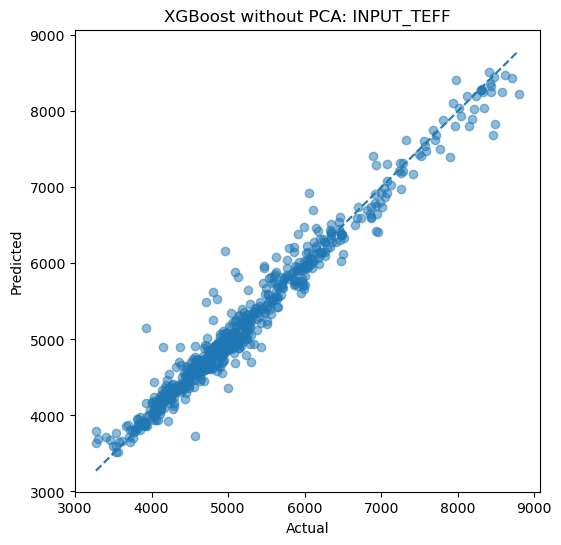

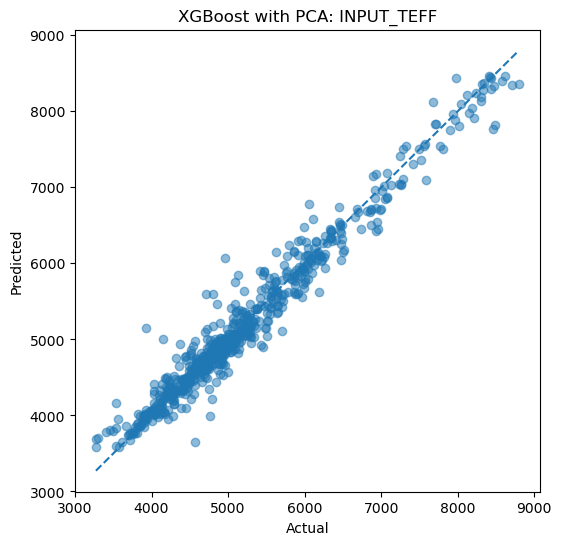

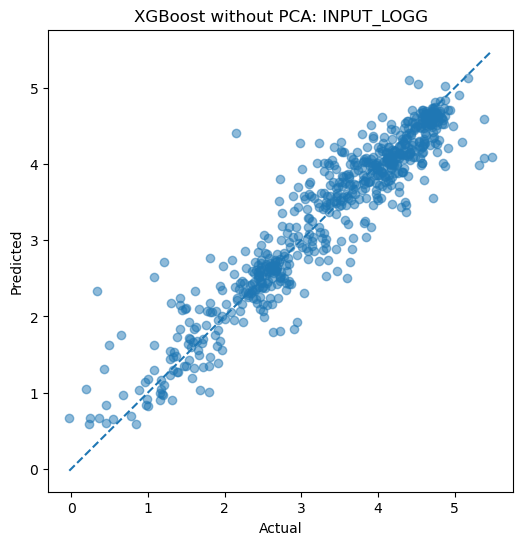

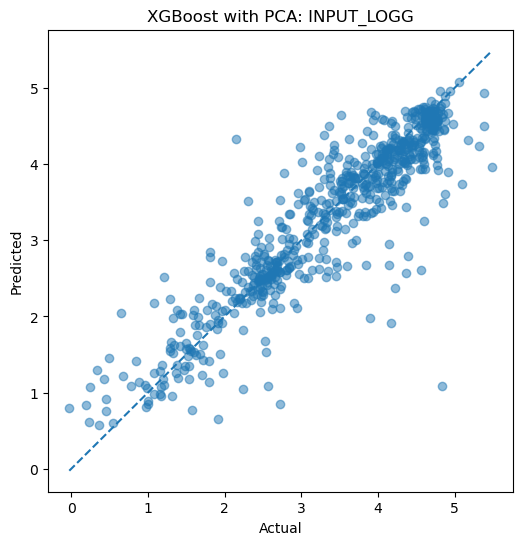

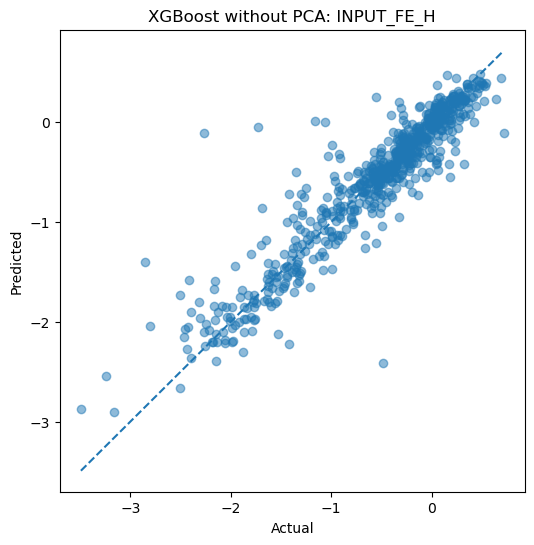

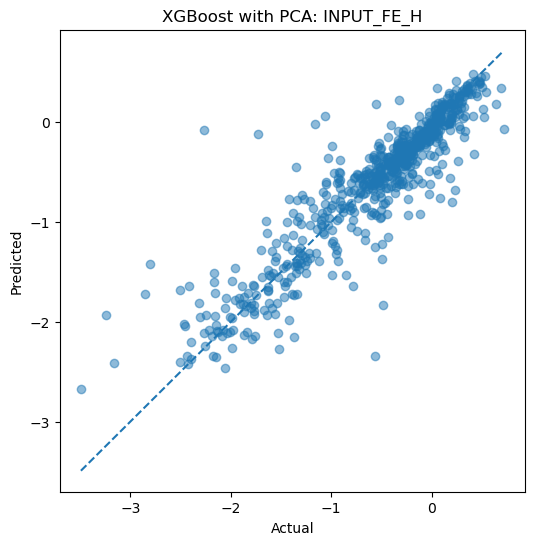

In [ ]:
import matplotlib.pyplot as plt

def plot_predicted_vs_actual_single_target(y_true, y_pred, target_name, model_name):

    actual = y_true[target_name]
    predicted = y_pred

    plt.figure(figsize=(6, 6))
    plt.scatter(actual, predicted, alpha=0.5)

    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name}: {target_name}")
    plt.show()

for (model_name, target), pred in xgb_predictions.items():
    plot_predicted_vs_actual_single_target(
        y_test,
        pred,
        target,
        model_name
    )

## 13. Feature Importance

In [ ]:
# Feature Importance Analysis
# We use XGBoost without PCA because it was the best overall model.
# Since no PCA is applied, feature importance maps directly to original wavelength bins.
target_cols = ["INPUT_TEFF", "INPUT_LOGG", "INPUT_FE_H"]

importance_tables = {}

for target in target_cols:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("xgb", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        ))
    ])

    model.fit(X_train, y_train[target])
    pred = model.predict(X_test)

    xgb = model.named_steps["xgb"]
    importance = xgb.feature_importances_

    top_idx = np.argsort(importance)[::-1][:20]

    importance_df = pd.DataFrame({
        "Target": target,
        "Rank": range(1, 21),
        "Wavelength": wave[top_idx],
        "Feature_Index": top_idx,
        "Importance": importance[top_idx],
        "MAE": mean_absolute_error(y_test[target], pred),
        "R2": r2_score(y_test[target], pred)
    })

    importance_tables[target] = importance_df

    print(f"\nTop wavelengths for {target}")
    display(importance_df)


Top wavelengths for INPUT_TEFF


,Target,Rank,Wavelength,Feature_Index,Importance,MAE,R2
0,INPUT_TEFF,1,6561.452637,2581,0.077454,128.543452,0.966865
1,INPUT_TEFF,2,6559.941895,2580,0.075942,128.543452,0.966865
2,INPUT_TEFF,3,6567.498535,2585,0.069688,128.543452,0.966865
3,INPUT_TEFF,4,8757.900391,3835,0.055268,128.543452,0.966865
4,INPUT_TEFF,5,6569.011230,2586,0.047850,128.543452,0.966865
5,INPUT_TEFF,6,4855.120117,1273,0.036931,128.543452,0.966865
6,INPUT_TEFF,7,4864.072266,1281,0.035923,128.543452,0.966865
7,INPUT_TEFF,8,4337.105469,783,0.027521,128.543452,0.966865
8,INPUT_TEFF,9,8437.232422,3673,0.025189,128.543452,0.966865
9,INPUT_TEFF,10,3893.139893,314,0.024014,128.543452,0.966865



Top wavelengths for INPUT_LOGG


,Target,Rank,Wavelength,Feature_Index,Importance,MAE,R2
0,INPUT_LOGG,1,5251.701172,1614,0.057747,0.268047,0.887364
1,INPUT_LOGG,2,4410.623535,856,0.044213,0.268047,0.887364
2,INPUT_LOGG,3,5250.492188,1613,0.038772,0.268047,0.887364
3,INPUT_LOGG,4,3936.406982,362,0.035345,0.268047,0.887364
4,INPUT_LOGG,5,4205.329102,649,0.029313,0.268047,0.887364
5,INPUT_LOGG,6,4771.995117,1198,0.025774,0.268047,0.887364
6,INPUT_LOGG,7,5164.163574,1541,0.024871,0.268047,0.887364
7,INPUT_LOGG,8,3935.500732,361,0.022390,0.268047,0.887364
8,INPUT_LOGG,9,3934.594727,360,0.018246,0.268047,0.887364
9,INPUT_LOGG,10,5165.353027,1542,0.017023,0.268047,0.887364



Top wavelengths for INPUT_FE_H


,Target,Rank,Wavelength,Feature_Index,Importance,MAE,R2
0,INPUT_FE_H,1,5891.148926,2113,0.082836,0.170777,0.864083
1,INPUT_FE_H,2,4873.040039,1289,0.023069,0.170777,0.864083
2,INPUT_FE_H,3,4482.290527,926,0.022756,0.170777,0.864083
3,INPUT_FE_H,4,4874.162598,1290,0.021137,0.170777,0.864083
4,INPUT_FE_H,5,5101.524902,1488,0.020442,0.170777,0.864083
5,INPUT_FE_H,6,4667.668457,1102,0.020190,0.170777,0.864083
6,INPUT_FE_H,7,9259.765625,4077,0.019514,0.170777,0.864083
7,INPUT_FE_H,8,5003.800781,1404,0.015768,0.170777,0.864083
8,INPUT_FE_H,9,4985.399902,1388,0.014998,0.170777,0.864083
9,INPUT_FE_H,10,5184.417969,1558,0.014407,0.170777,0.864083


## 14. Feature-Representation Ablation

In [ ]:
# Ablation table comparing model families with and without PCA.
# Ridge with PCA is compared against Ridge without PCA to measure the effect of dimensionality reduction.
# Random Forest and XGBoost are compared with and without PCA to evaluate whether nonlinear models benefit from the raw wavelength representation.
ablation_results = all_results[
    all_results["Model"].isin([
        "Ridge without PCA",
        "Ridge with PCA",
        "RandomForest without PCA",
        "RandomForest with PCA",
        "XGBoost without PCA",
        "XGBoost with PCA"
    ])
].sort_values(["Target", "Model"])

display(ablation_results)



,Model,Target,MAE,R2
11,RandomForest with PCA,INPUT_FE_H,0.253870,0.759939
8,RandomForest without PCA,INPUT_FE_H,0.323940,0.653789
5,Ridge with PCA,INPUT_FE_H,0.228188,0.738636
2,Ridge without PCA,INPUT_FE_H,0.501452,-0.493322
17,XGBoost with PCA,INPUT_FE_H,0.192674,0.828418
16,XGBoost without PCA,INPUT_FE_H,0.170777,0.864083
10,RandomForest with PCA,INPUT_LOGG,0.451894,0.711696
7,RandomForest without PCA,INPUT_LOGG,0.467603,0.727666
4,Ridge with PCA,INPUT_LOGG,0.327134,0.788546
1,Ridge without PCA,INPUT_LOGG,0.793714,-0.441123


## 15. Sensitivity Analysis

In [ ]:
# XGBoost sensitivity analysis: number of estimators
# The purpose is to check whether model performance is still improving after initial baseline of 300.

sensitivity_results = []

estimator_values = [50, 100, 150, 200, 300, 400, 500, 700, 900]

for n in estimator_values:
    for target in target_cols:
        model = XGBRegressor(
            n_estimators=n,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        )

        model.fit(X_train, y_train[target])
        pred = model.predict(X_test)

        sensitivity_results.append({
            "Target": target,
            "n_estimators": n,
            "MAE": mean_absolute_error(y_test[target], pred),
            "R2": r2_score(y_test[target], pred)
        })

sensitivity_df = pd.DataFrame(sensitivity_results)
display(sensitivity_df)


,Target,n_estimators,MAE,R2
0,INPUT_TEFF,50,169.354120,0.953308
1,INPUT_LOGG,50,0.334636,0.842965
2,INPUT_FE_H,50,0.213991,0.822283
3,INPUT_TEFF,100,134.137538,0.965201
4,INPUT_LOGG,100,0.283134,0.877064
5,INPUT_FE_H,100,0.182066,0.853031
6,INPUT_TEFF,150,129.782549,0.966440
7,INPUT_LOGG,150,0.275107,0.882146
8,INPUT_FE_H,150,0.176121,0.859135
9,INPUT_TEFF,200,129.064662,0.966623


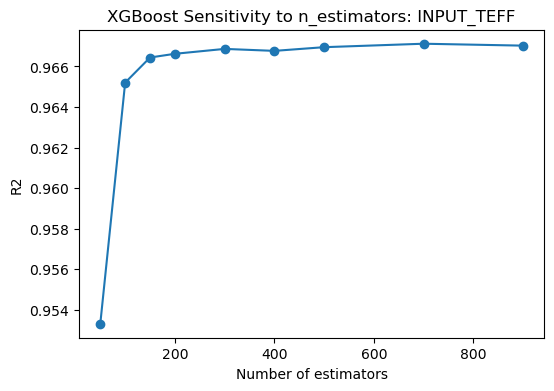

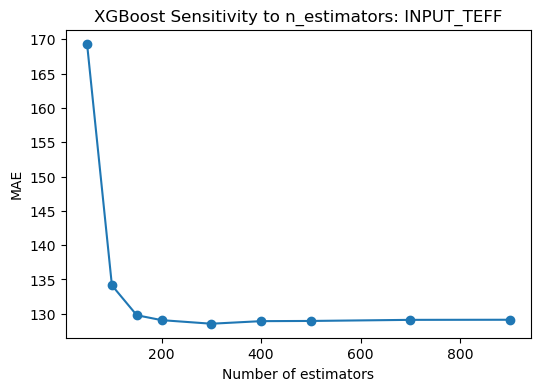

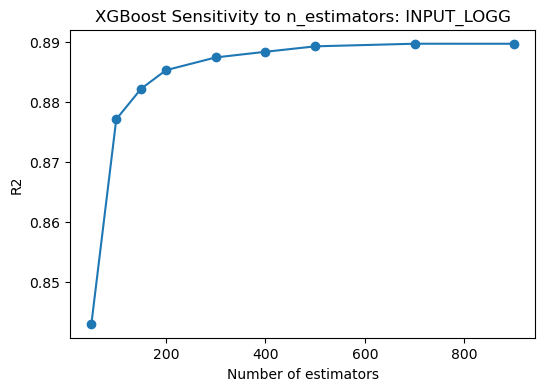

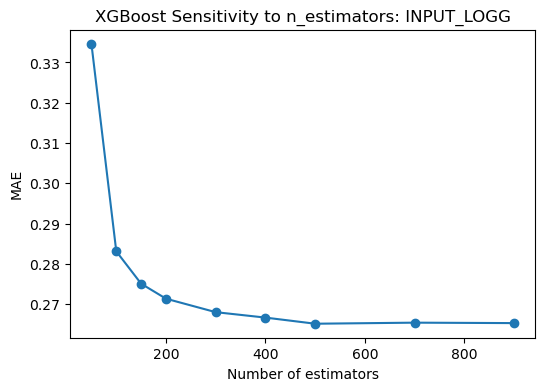

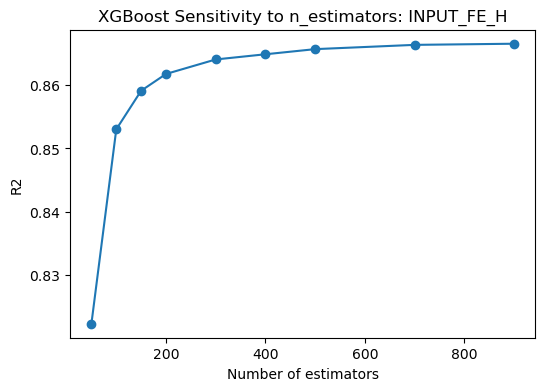

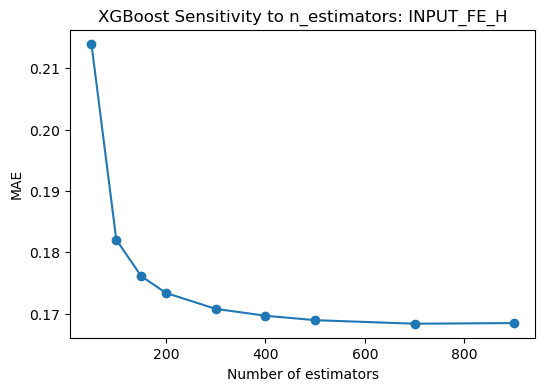

In [ ]:
# Plot n_estimators sensitivity for each target.

for target in target_cols:
    subset = sensitivity_df[sensitivity_df["Target"] == target]

    plt.figure(figsize=(6, 4))
    plt.plot(subset["n_estimators"], subset["R2"], marker="o")
    plt.xlabel("Number of estimators")
    plt.ylabel("R2")
    plt.title(f"XGBoost Sensitivity to n_estimators: {target}")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(subset["n_estimators"], subset["MAE"], marker="o")
    plt.xlabel("Number of estimators")
    plt.ylabel("MAE")
    plt.title(f"XGBoost Sensitivity to n_estimators: {target}")
    plt.show()


## 16. Ridge + PCA Cross-Validation Diagnostics

In [ ]:

# Debug Ridge with PCA fold-by-fold

ridge_pca_debug = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("ridge", Ridge(alpha=1.0))
])

ridge_debug_results = []

for target in target_cols:
    for fold_num, (train_idx, test_idx) in enumerate(cv_splits, start=1):

        X_train_fold = X[train_idx]
        X_test_fold = X[test_idx]

        y_train_fold = y[target].iloc[train_idx]
        y_test_fold = y[target].iloc[test_idx]

        ridge_pca_debug.fit(X_train_fold, y_train_fold)
        pred = ridge_pca_debug.predict(X_test_fold)

        ridge_debug_results.append({
            "Target": target,
            "Fold": fold_num,
            "R2": r2_score(y_test_fold, pred),
            "MAE": mean_absolute_error(y_test_fold, pred),
            "PCA_components": ridge_pca_debug.named_steps["pca"].n_components_
        })

ridge_debug_df = pd.DataFrame(ridge_debug_results)
display(ridge_debug_df)

,Target,Fold,R2,MAE,PCA_components
0,INPUT_TEFF,1,0.943314,167.706658,671
1,INPUT_TEFF,2,-142.661654,670.289690,679
2,INPUT_TEFF,3,0.922433,176.231442,676
3,INPUT_TEFF,4,0.920224,179.605293,671
4,INPUT_TEFF,5,-2566.329121,2374.228816,696
5,INPUT_LOGG,1,0.831143,0.316200,671
6,INPUT_LOGG,2,-105.815292,0.793529,679
7,INPUT_LOGG,3,0.813790,0.313372,676
8,INPUT_LOGG,4,0.790848,0.324066,671
9,INPUT_LOGG,5,-6498.514873,4.193824,696


## Additional Sensitivity Analysis: Tree Depth

The first sensitivity check varies the number of estimators. The second check varies tree depth while holding the rest of the XGBoost settings fixed. This helps separate the effect of model capacity from the effect of boosting duration.


In [ ]:
# XGBoost sensitivity analysis: max_depth

max_depth_results = []
depth_values = [2, 3, 4, 5, 6, 8]

for depth in depth_values:
    for target in target_cols:
        model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=depth,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        )

        model.fit(X_train, y_train[target])
        pred = model.predict(X_test)

        max_depth_results.append({
            "Target": target,
            "max_depth": depth,
            "MAE": mean_absolute_error(y_test[target], pred),
            "R2": r2_score(y_test[target], pred)
        })

max_depth_df = pd.DataFrame(max_depth_results)
display(max_depth_df)


,Target,max_depth,MAE,R2
0,INPUT_TEFF,2,134.719847,0.965146
1,INPUT_LOGG,2,0.277894,0.879053
2,INPUT_FE_H,2,0.182326,0.857588
3,INPUT_TEFF,3,128.543452,0.966865
4,INPUT_LOGG,3,0.268047,0.887364
5,INPUT_FE_H,3,0.170777,0.864083
6,INPUT_TEFF,4,126.014617,0.966526
7,INPUT_LOGG,4,0.261105,0.891488
8,INPUT_FE_H,4,0.169482,0.866940
9,INPUT_TEFF,5,125.342533,0.966173


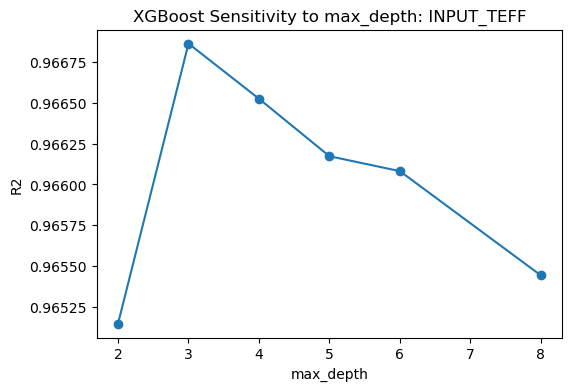

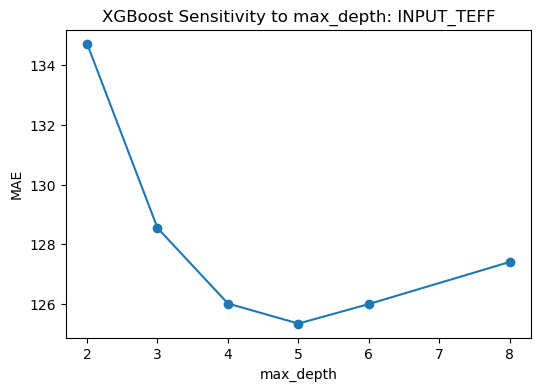

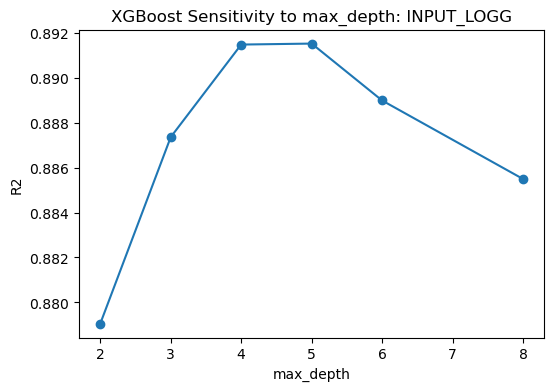

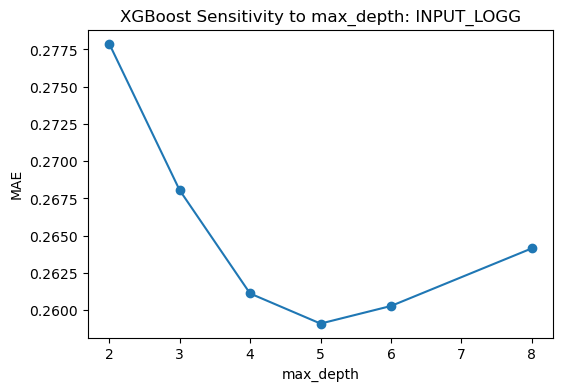

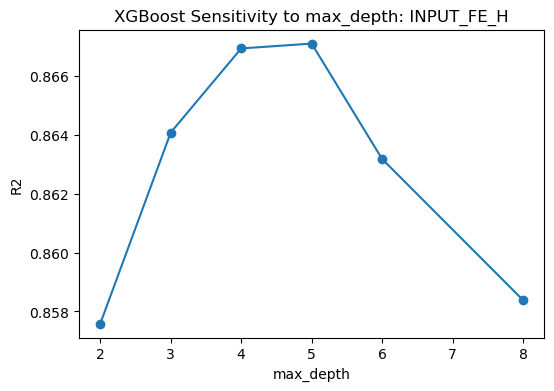

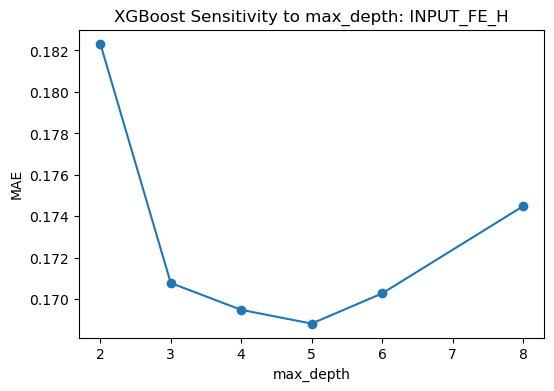

In [ ]:
# Plot max_depth sensitivity for each target.

for target in target_cols:
    subset = max_depth_df[max_depth_df["Target"] == target]

    plt.figure(figsize=(6, 4))
    plt.plot(subset["max_depth"], subset["R2"], marker="o")
    plt.xlabel("max_depth")
    plt.ylabel("R2")
    plt.title(f"XGBoost Sensitivity to max_depth: {target}")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(subset["max_depth"], subset["MAE"], marker="o")
    plt.xlabel("max_depth")
    plt.ylabel("MAE")
    plt.title(f"XGBoost Sensitivity to max_depth: {target}")
    plt.show()


# Failure Analysis

The goal of this section is to identify specific test-set records where the final supervised model failed

In [ ]:
# Failure Analysis: Find test records with the largest prediction errors
# The goal is to identify specific stars where the final model performed poorly.

final_models = {}

# Start with metadata for the test set
failure_df = meta_test.reset_index().rename(columns={"index": "Original_Index"}).copy()

# Train one final XGBoost model for each target and store predictions
for target in target_cols:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("xgb", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective="reg:squarederror"
        ))
    ])

    model.fit(X_train, y_train[target])
    pred = model.predict(X_test)

    final_models[target] = model

    failure_df[f"Actual_{target}"] = y_test[target].values
    failure_df[f"Predicted_{target}"] = pred
    failure_df[f"Abs_Error_{target}"] = np.abs(y_test[target].values - pred)

In [ ]:
# Because the three targets have different units,
# raw errors are not directly comparable.
#
# Teff is measured in Kelvin, so its error can be hundreds.
# log g and [Fe/H] are much smaller scale values.
#
# To compare errors across targets, divide each absolute error
# by the training-set standard deviation of that target.

for target in target_cols:
    failure_df[f"Scaled_Error_{target}"] = (
        failure_df[f"Abs_Error_{target}"] / y_train[target].std()
    )

scaled_error_cols = [f"Scaled_Error_{target}" for target in target_cols]

failure_df["Total_Scaled_Error"] = failure_df[scaled_error_cols].sum(axis=1)

failure_df["Worst_Target"] = (
    failure_df[scaled_error_cols]
    .idxmax(axis=1)
    .str.replace("Scaled_Error_", "", regex=False)
)

In [ ]:
# Show the records with the largest overall prediction errors.
# These are candidate examples for the failure analysis section.

id_cols = [
    col for col in
    ["Original_Index", "MANGAID", "mangaid", "SPECTRAL_TYPE", "S2N", "BADPIXFRAC"]
    if col in failure_df.columns
]

error_cols = []

for target in target_cols:
    error_cols += [
        f"Actual_{target}",
        f"Predicted_{target}",
        f"Abs_Error_{target}"
    ]

display_cols = id_cols + ["Worst_Target", "Total_Scaled_Error"] + error_cols

top_failures = (
    failure_df
    .sort_values("Total_Scaled_Error", ascending=False)
    [display_cols]
    .head(10)
)

top_failures

,Original_Index,MANGAID,SPECTRAL_TYPE,Worst_Target,Total_Scaled_Error,Actual_INPUT_TEFF,Predicted_INPUT_TEFF,Abs_Error_INPUT_TEFF,Actual_INPUT_LOGG,Predicted_INPUT_LOGG,Abs_Error_INPUT_LOGG,Actual_INPUT_FE_H,Predicted_INPUT_FE_H,Abs_Error_INPUT_FE_H
626,2257,7-17129068,K,INPUT_FE_H,5.606003,4798.8100,5624.252930,825.442930,2.144000,4.401478,2.257478,-2.269000,-0.108916,2.160084
606,955,3-151550654,K,INPUT_FE_H,4.043756,4895.3037,5064.806641,169.502941,1.216210,2.709675,1.493465,-0.480320,-2.408557,1.928238
67,960,3-151672729,K,INPUT_FE_H,3.045430,4377.9937,4898.126465,520.132765,2.887876,3.579184,0.691308,-2.855197,-1.399371,1.455826
610,1783,60-2051287173829740032,M,INPUT_LOGG,3.032123,3302.6000,3695.881104,393.281104,0.337910,2.329493,1.991583,0.179110,-0.548812,0.727922
104,3060,7-7079819,K,INPUT_TEFF,2.935028,4958.0737,6165.948242,1207.874542,3.228144,4.278104,1.049959,-1.031999,-0.341785,0.690215
538,684,3-139937884,K,INPUT_FE_H,2.856939,4210.7200,3927.503174,283.216826,4.165000,4.524522,0.359522,-1.727000,-0.044856,1.682144
442,2434,7-18053524,K,INPUT_FE_H,2.754945,5125.1934,5821.583984,696.390584,3.426123,4.216465,0.790342,-1.058444,0.004504,1.062948
13,766,3-142072281,K,INPUT_TEFF,2.440749,3925.9000,5150.730957,1224.830957,5.387140,4.082943,1.304197,-0.344950,-0.185720,0.159230
131,2000,7-11077539,G,INPUT_FE_H,2.305933,5463.5600,5936.171387,472.611387,3.014000,3.933495,0.919495,-0.549000,0.255530,0.804530
581,1759,60-1995012897413744384,A,INPUT_FE_H,2.193289,7984.2000,8411.835938,427.635938,5.090470,4.294256,0.796214,-1.686200,-0.857807,0.828393


In [ ]:
# Check whether some spectral types have larger errors than others.

if "SPECTRAL_TYPE" in failure_df.columns:
    spectral_error_summary = (
        failure_df
        .groupby("SPECTRAL_TYPE")
        .agg(
            Count=("SPECTRAL_TYPE", "size"),
            Mean_Total_Scaled_Error=("Total_Scaled_Error", "mean"),
            Median_Total_Scaled_Error=("Total_Scaled_Error", "median")
        )
        .sort_values("Mean_Total_Scaled_Error", ascending=False)
    )

spectral_error_summary

,Count,Mean_Total_Scaled_Error,Median_Total_Scaled_Error
SPECTRAL_TYPE,,,
M,14,0.981692,0.654359
A,36,0.820768,0.681023
G,127,0.606055,0.501659
F,94,0.579667,0.499863
K,388,0.529280,0.370394


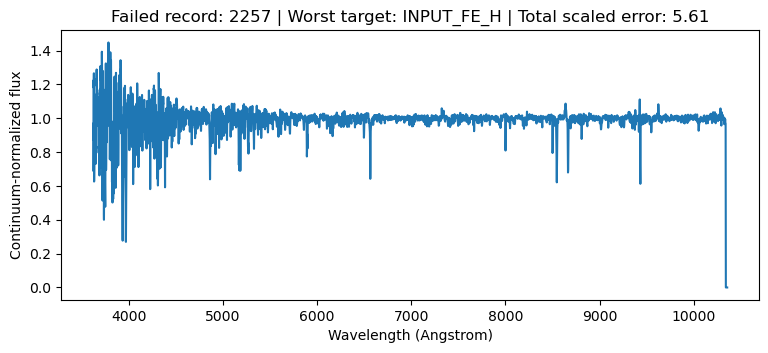

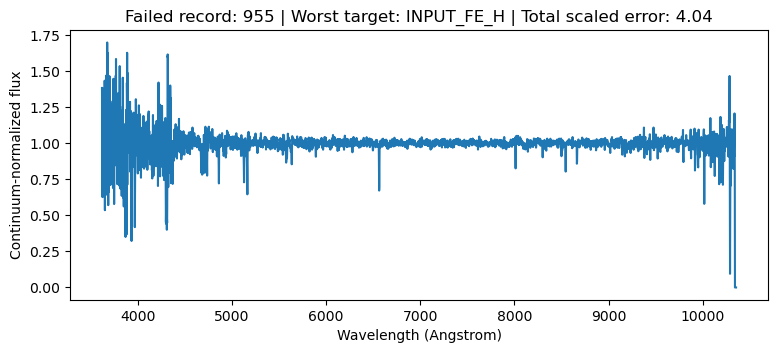

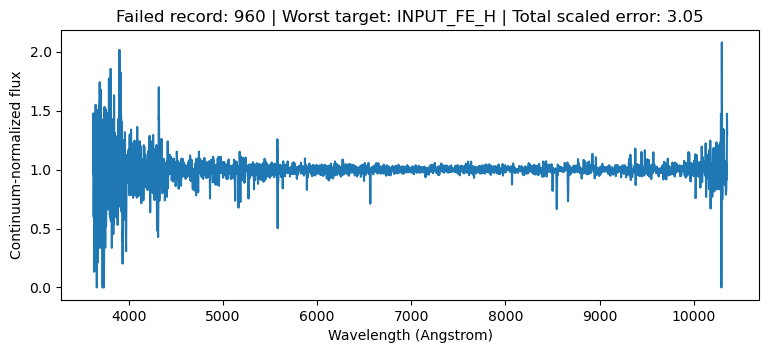

In [ ]:
# Plot the top 3 failed records.
# These plots help check whether the spectra look noisy, unusual, or different from normal cases.

top_3_indices = top_failures["Original_Index"].head(3).values

for original_index in top_3_indices:

    test_position = failure_df.index[failure_df["Original_Index"] == original_index][0]
    row = failure_df.loc[test_position]

    plt.figure(figsize=(9, 3.5))
    plt.plot(wave, X_test[test_position])
    plt.xlabel("Wavelength (Angstrom)")
    plt.ylabel("Continuum-normalized flux")
    plt.title(
        f"Failed record: {original_index} | "
        f"Worst target: {row['Worst_Target']} | "
        f"Total scaled error: {row['Total_Scaled_Error']:.2f}"
    )
    plt.show()